<a href="https://colab.research.google.com/github/athfizh/PCVK26_05_Hafizh/blob/main/Modul%201/P1_TugasD2_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Athaulla Hafizh

Absen : 05

Kelas : TI-3F

NIM   : 244107020030

**D2. Pengenalan Python untuk membaca dan menampilkan image dengan
pengenalan macam-macam Library (Numpy, pandas, cv2, skimage, PIL dan
matplotlib)**

---

In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt
import requests
import numpy as np

--- Menampilkan Citra dari URL ---


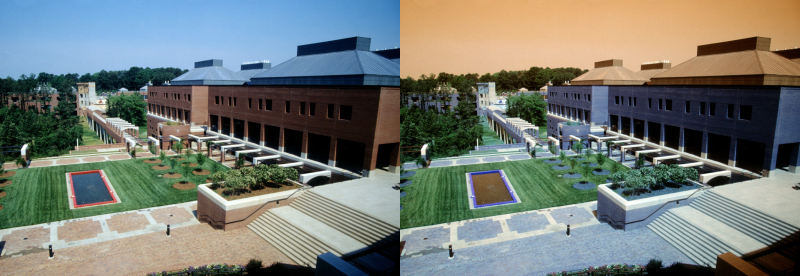

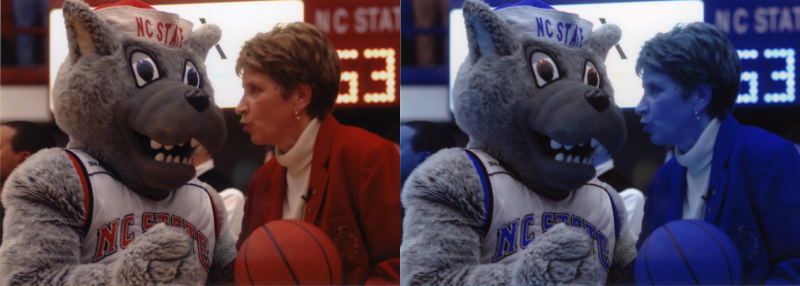

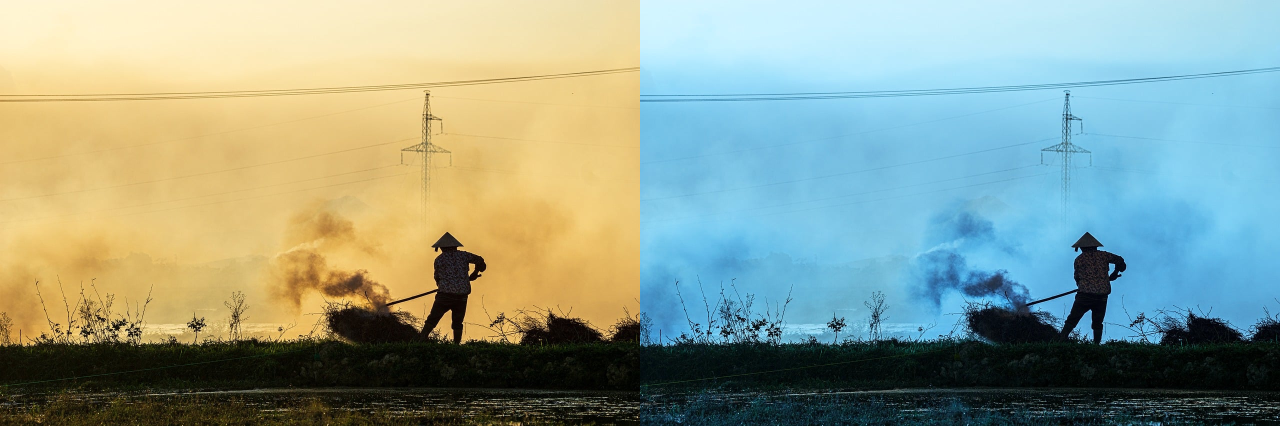

In [2]:
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://cdn.pixabay.com/photo/2025/09/26/08/04/labor-9856448_1280.jpg"
]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

print("--- Menampilkan Citra dari URL ---")
for url in urls:
    try:
        if "pixabay.com" in url:
            resp = requests.get(url, headers=headers, timeout=10)
            resp.raise_for_status()
            image_array = np.frombuffer(resp.content, dtype=np.uint8)
            image = cv.imdecode(image_array, cv.IMREAD_COLOR)  # hasil langsung format BGR
        else:
            image = io.imread(url)
            image = cv.cvtColor(image, cv.COLOR_RGB2BGR)  # io.imread hasilnya RGB, samakan ke BGR

        image = cv.resize(image, (0,0), fx=0.5, fy=0.5) # Resize setengah ukuran
        image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB
        final_frame = cv.hconcat((image, image_2))      # Gabung citra asli & RGB
        cv2_imshow(final_frame)
        print('\n')
    except Exception as e:
        print(f"Gagal memuat {url}: {e}\n")

Resolusi image: tinggi x lebar = 426 x 640


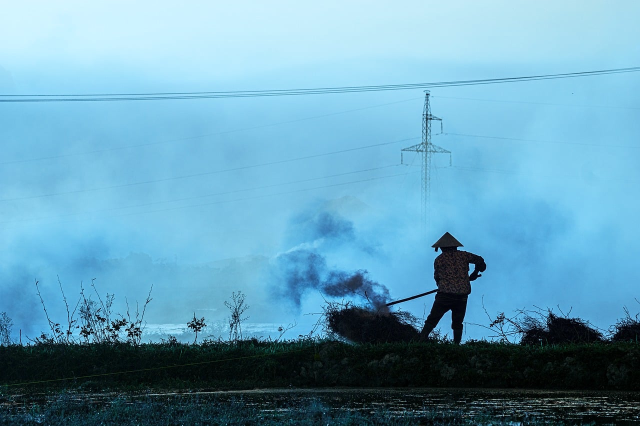

In [3]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print(f"Resolusi image: tinggi x lebar = {tinggi} x {lebar}")
cv2_imshow(image_2)
print('\n')

--- Menambahkan Garis Horizontal Penuh ---


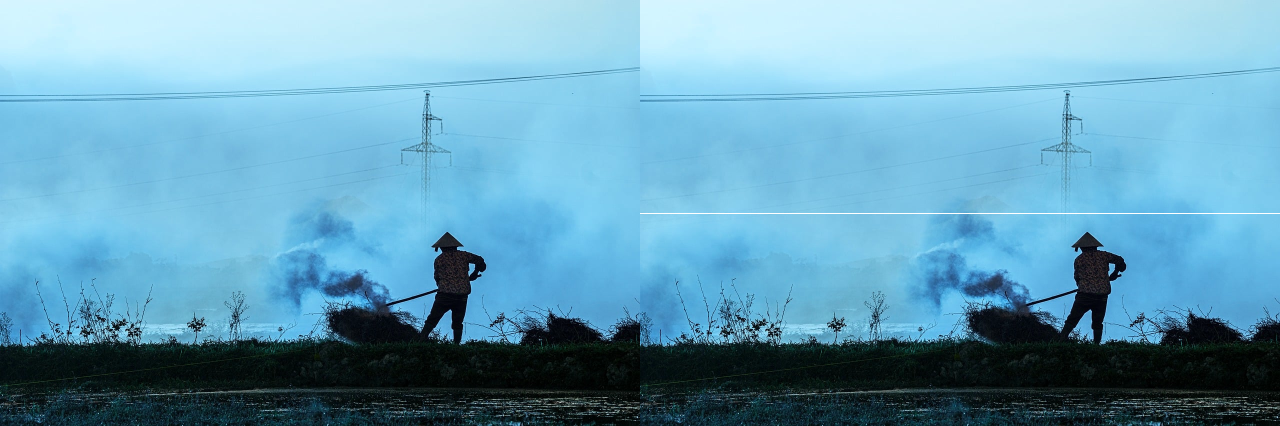

In [4]:
print("--- Menambahkan Garis Horizontal Penuh ---")
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Membuat garis horizontal di tengah image dengan manipulasi piksel (loop)
for y in range(lebar):
    image_3[int(tinggi/2), y] = [255, 255, 255] # [255,255,255] = warna putih

final_frame_garis = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame_garis)

**PERTANYAAN PRAKTIKUM D2**

1. Jelaskan mengapa modul praktikum ini ekseskusi Python dilakukan menggunakan Google Colab?

    Jawab: Eksekusi kode Python dilakukan di Google Colab karena platform ini berbasis cloud, sehingga mahasiswa tidak perlu melakukan instalasi IDE atau konfigurasi library di komputer lokal. Selain itu, Colab terintegrasi dengan Google Drive, mendukung kolaborasi, serta menyediakan akses komputasi tingkat tinggi (GPU/TPU) secara gratis yang sangat esensial untuk pemrosesan citra digital.

2.  Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke delapan? Apakah semua library tersebut harus digunakan dalam praktikum sesi ini?  

    Jawab:
     - Numpy (np): Untuk manipulasi data matriks (array multidimensi) karena citra digital pada dasarnya direpresentasikan sebagai matriks angka.
     - Pandas (pd): Untuk analisis dan manipulasi struktur data tabular (DataFrames).
     - cv2 (OpenCV): Library inti untuk pemrosesan citra dan computer vision (membaca, mengubah warna, manipulasi piksel).
     - skimage (io, transform): Library pemrosesan citra (pada kode digunakan io.imread untuk membaca gambar langsung dari URL internet).
     - PIL (Python Imaging Library): Untuk membuka, memanipulasi, dan menyimpan format file gambar.
     - matplotlib.pylab (plt): Untuk visualisasi data dan mengeplot gambar (image plotting) ke layar.
  
    **Apakah semua harus digunakan?**
    
    Tidak. Penggunaan library disesuaikan dengan kebutuhan instruksi kode. Jika dalam satu sesi praktikum tidak ada tugas analisis data tabular atau manipulasi format file eksternal, maka library seperti pandas atau PIL tidak wajib digunakan.

3. Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut image = cv.resize(image, (0,0), fx=0.5, fy=0.5). Apa kegunaan kode program tersebut?dan apa pengaruhnya jika tidak dilakukan?

    Jawab:
    - Kegunaan: Kode image = cv.resize(image, (0,0), fx=0.5, fy=0.5) berfungsi untuk mengubah skala ukuran (resolusi) gambar menjadi setengah (50% atau 0.5) dari ukuran aslinya pada sumbu horizontal (fx) maupun vertikal (fy).

    - Pengaruh jika tidak dilakukan: Gambar akan dipertahankan pada resolusi aslinya. Jika ukuran asli gambar dari URL sangat besar, hal ini akan memakan alokasi memori (RAM) yang lebih tinggi, memperberat proses kompilasi visual, dan membuat hasil gambar menjadi terpotong atau sangat besar saat ditampilkan bersampingan menggunakan fungsi cv.hconcat.

4. Apakah kegunaan kode [255,255,255] ? Jelaskan!

    Jawab: Kode tersebut digunakan untuk menyuntikkan warna putih murni pada titik piksel yang dituju. Pada sistem citra berwarna 8-bit yang memiliki 3 channel (seperti RGB atau BGR di OpenCV), rentang nilainya adalah 0 hingga 255. Nilai 255 pada ketiga channel (Blue=255, Green=255, Red=255) merepresentasikan intensitas cahaya penuh dari ketiga warna dasar yang bila digabungkan akan memproyeksikan piksel berwarna putih.

5. Jelaskan keterkaitan antara pixel dan resolusi gambar yang tinggi ataupun rendah!

    Jawab: Pixel (piksel) adalah unit elemen terkecil berbentuk kotak yang menyusun sebuah citra digital dan menyimpan nilai warna. Resolusi adalah ukuran dimensi yang menyatakan total jumlah piksel dalam gambar tersebut (lebar × tinggi). Keterkaitannya berbanding lurus: citra beresolusi tinggi berarti gambar tersebut tersusun dari piksel yang sangat banyak dan padat, sehingga mampu merepresentasikan detail visual dengan sangat tajam dan tidak pecah. Sebaliknya, citra beresolusi rendah memiliki jumlah piksel yang sedikit, sehingga detailnya kurang dan bentuk kotak-kotak pikselnya (aliasing / pixelated) akan terlihat jelas oleh mata.

**TUGAS PRAKTIKUM D2**

--- Output Tugas 2: Garis Vertikal dan Menyilang Diagonal ---


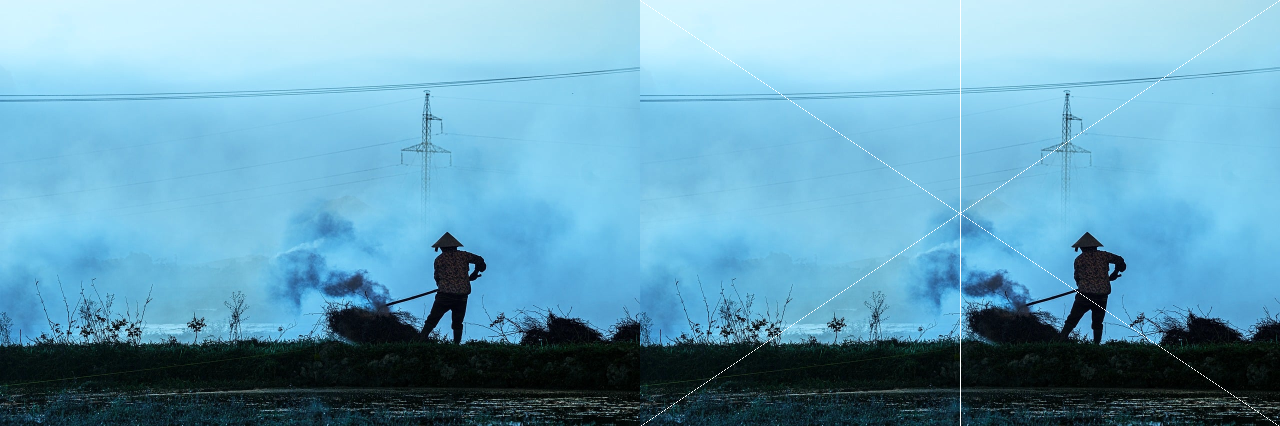

In [5]:
# Membuat kanvas baru agar tidak menimpa gambar sebelumnya
img_tugas2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# a. Garis vertikal di tengah
for x in range(tinggi):
    img_tugas2[x, int(lebar/2)] = [255, 255, 255]

# b. Garis diagonal (kiri atas ke kanan bawah)
for x in range(tinggi):
    y = int(x * lebar / tinggi)
    # Pengecekan agar index y tidak melebihi lebar gambar
    if y < lebar:
        img_tugas2[x, y] = [255, 255, 255]

# c. Garis diagonal (kanan atas ke kiri bawah)
for x in range(tinggi):
    y = (lebar - 1) - int(x * lebar / tinggi)
    # Pengecekan agar index y tidak minus
    if y >= 0:
        img_tugas2[x, y] = [255, 255, 255]

print("--- Output Tugas 2: Garis Vertikal dan Menyilang Diagonal ---")
# Menggabungkan gambar asli (kiri) dan hasil manipulasi (kanan)
cv2_imshow(cv.hconcat((image_2, img_tugas2)))
print('\n')

--- Output Tugas 3: Garis Horisontal Panjang Tertentu ---


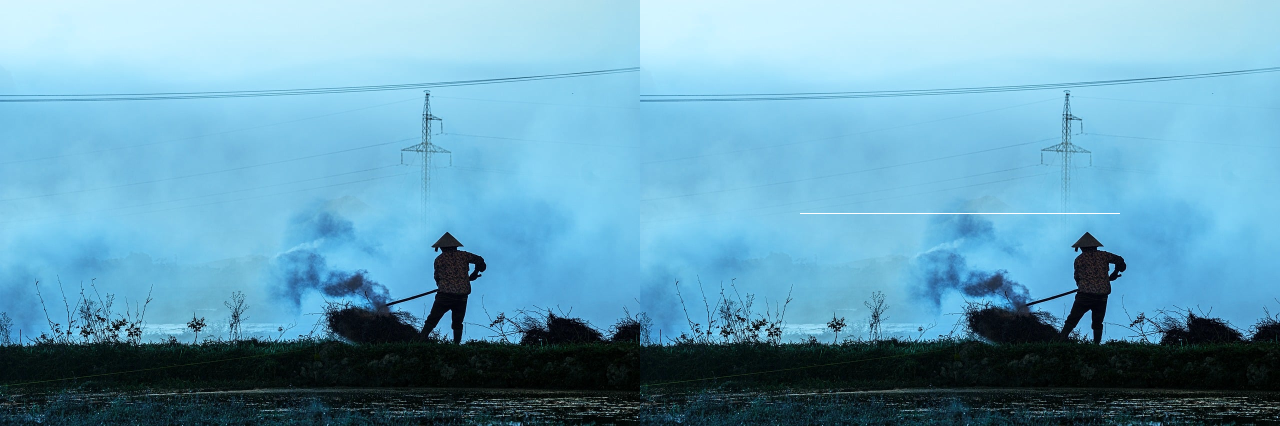

In [6]:
img_tugas3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Membatasi rentang kolom (y) agar garis hanya terbentuk di area tengah
# Contoh: kita buat garis dari 1/4 lebar gambar hingga 3/4 lebar gambar
for y in range(int(lebar / 4), int(3 * lebar / 4)):
    img_tugas3[int(tinggi / 2), y] = [255, 255, 255]

print("--- Output Tugas 3: Garis Horisontal Panjang Tertentu ---")
cv2_imshow(cv.hconcat((image_2, img_tugas3)))
print('\n')

--- Output Tugas 4: Kotak Kumpulan Pixel Putih ---


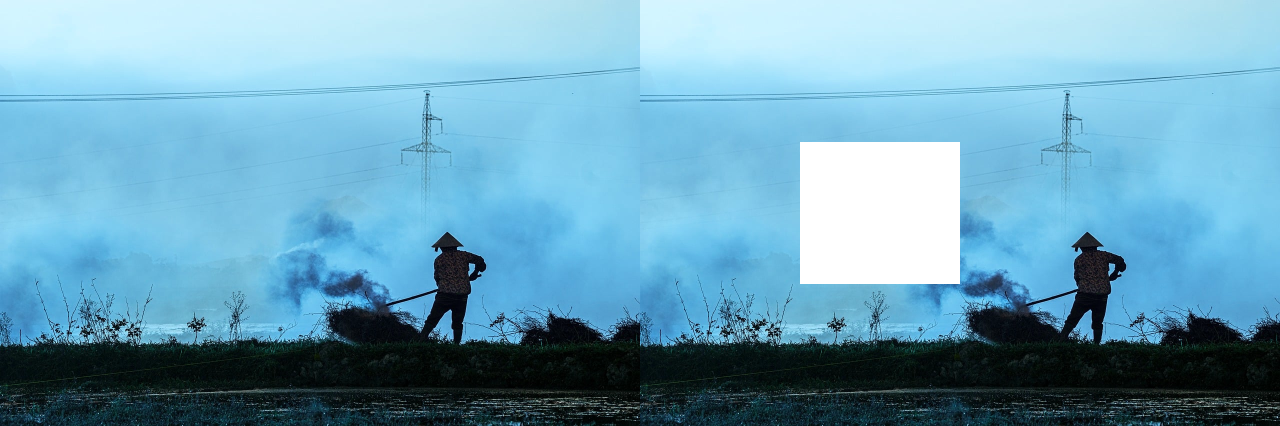

In [7]:
img_tugas4 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Menggunakan perulangan ganda (nested loop) untuk mengisi blok pixel
# Loop x untuk tinggi kotak (baris), Loop y untuk lebar kotak (kolom)
# Contoh diletakkan sembarang di koordinat tertentu
for x in range(int(tinggi / 3), int(2 * tinggi / 3)):
    for y in range(int(lebar / 4), int(2 * lebar / 4)):
        img_tugas4[x, y] = [255, 255, 255]

print("--- Output Tugas 4: Kotak Kumpulan Pixel Putih ---")
cv2_imshow(cv.hconcat((image_2, img_tugas4)))